In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_data=pd.read_csv('/content/train.csv',sep=',')#kaggle에서 다운받음
test_data=pd.read_csv('/content/test.csv',sep=',')

In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
'''new_columns=data.columns.str.split(',')
new_columns'''
#처음에 모든 값들이 붙어 있었음. 파일 열 때부터 ','로 분리 or 아래 과정 실행
'''data_clean=data.iloc[:,0].str.split(',',expand=True)
data_clean[3]=data_clean[3]+data_clean[4]
data_clean.drop(columns=4,axis=1,inplace=True)
data_clean.head()'''
#column분리 했더니 이중 괄호 형태로 나옴-->0번째 요소만 꺼내기로 해결
'''data_clean.columns=new_columns[0]
data_clean.head()'''
#처음에 모든 값들이 문자열 형태여서 정수 형태로 바꾼 후 아래 과정 진행(astype로 바꿈)
'''# 대문자 'I'인 'Int64' 사용!
cols = ['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch']

# 문자열 중 변환 불가능한 공백 등은 pd.to_numeric으로 미리 처리 후 Int64 변환
for col in cols:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce').astype('Int64')
# errors='coerce' 옵션이 숫자가 아닌 이상한 값을 자동으로 NaN 처리해 줍니다.
train_data['Age'] = pd.to_numeric(train_data['Age'], errors='coerce').astype('Float64')
train_data['Fare'] = pd.to_numeric(train_data['Fare'], errors='coerce').astype('Float64')'''

#컬럼 종류에 따라 분류하기(살짝은 잘못되긴 함)
'''num_cols= data_clean.select_dtypes(include=['Int64','Float64']).columns
str_cols= data_clean.select_dtypes(include=['object']).columns
cat_cols=['Pclass','Survived','Embarked']'''

"num_cols= data_clean.select_dtypes(include=['Int64','Float64']).columns\nstr_cols= data_clean.select_dtypes(include=['object']).columns\ncat_cols=['Pclass','Survived','Embarked']"

In [ ]:
summary=train_data.describe()
print(summary)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
cat_cols=['Pclass','Survived','Sex','Embarked','Age_unknown']
num_cols=list(set(train_data.select_dtypes(include=['Int64','Float64']).columns)-set(cat_cols))
str_cols=list(set(train_data.select_dtypes(exclude=['Int64','Float64']).columns)-set(cat_cols))


In [ ]:
num_cols

['SibSp', 'Fare', 'Parch', 'PassengerId', 'Age']

In [ ]:
train_data[num_cols].isna().sum()

,0
SibSp,0
Fare,0
Parch,0
PassengerId,0
Age,177


In [ ]:
train_data[['SibSp', 'PassengerId', 'Parch', 'Fare']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SibSp        891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Parch        891 non-null    int64  
 3   Fare         891 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 28.0 KB


<Axes: >

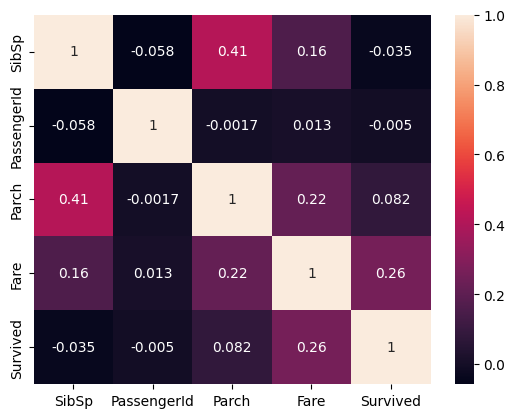

In [ ]:
sns.heatmap(train_data[['SibSp', 'PassengerId', 'Parch', 'Fare','Survived']].corr(),annot=True)

In [ ]:
train_data['Age_unknown']=train_data.Age.isna()
test_c_data=test_data.copy()
test_c_data['Age_unknown']=test_data.Age.isna()
train_data.Age_unknown
test_c_data.Age_unknown

,Age_unknown
0,False
1,False
2,False
3,False
4,False
...,...
413,True
414,False
415,False
416,True


In [ ]:
train_data.pivot_table(columns='Age_unknown', index='Sex',values='Survived',aggfunc='mean')

Age_unknown,False,True
Sex,,
female,0.754789,0.679245
male,0.205298,0.129032


<Axes: xlabel='Fare', ylabel='Count'>

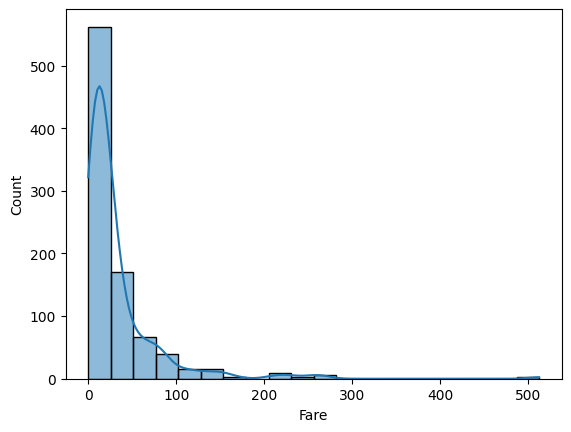

In [ ]:
sns.histplot(train_data.Fare,kde=True,bins=20)


(8, 8)


<Axes: >

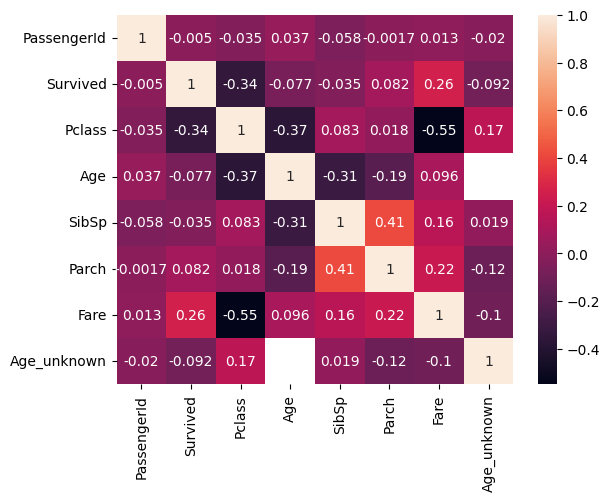

In [ ]:
corr_data=train_data.corr(numeric_only=True)
print(corr_data.shape)
sns.heatmap(corr_data,annot=True)
#Pclass,Fare가 가장 높은 영향,그 다음은 parch(kid,spouse),Age,sibSP

In [ ]:
data=pd.concat([train_data,test_c_data],axis=0)
#there's lots of rows with Survival missing because we binded test data with train_data
#so we'd better use data just for finding out correlation between variables

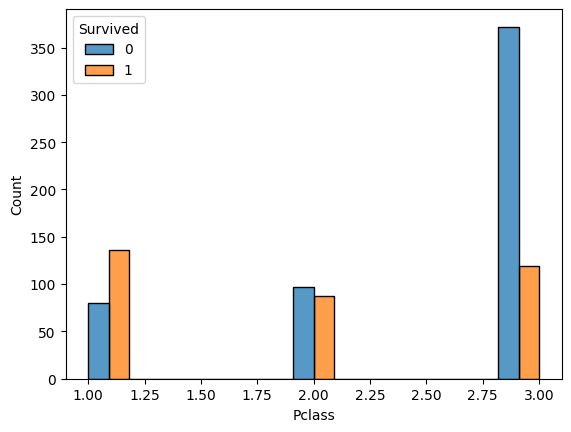

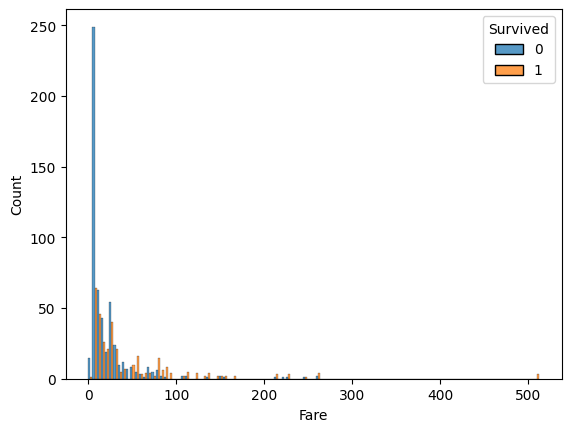

In [ ]:
sns.histplot(x='Pclass',hue='Survived',data=train_data,multiple='dodge')
plt.show()
sns.histplot(x='Fare',hue='Survived',data=train_data,multiple='dodge')
plt.show()

In [ ]:
train_data.groupby(by='Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [ ]:
print(str_cols)
print(cat_cols)
print(num_cols)
col_dic={'str_cols':str_cols,'cat_cols':cat_cols,'num_cols':num_cols}
col_dic

['Ticket', 'Name', 'Cabin']
['Pclass', 'Survived', 'Sex', 'Embarked', 'Age_unknown']
['SibSp', 'Fare', 'Parch', 'PassengerId', 'Age']


{'str_cols': ['Ticket', 'Name', 'Cabin'],
 'cat_cols': ['Pclass', 'Survived', 'Sex', 'Embarked', 'Age_unknown'],
 'num_cols': ['SibSp', 'Fare', 'Parch', 'PassengerId', 'Age']}

In [ ]:
train_data.groupby('Embarked')['Survived'].mean()


,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


In [ ]:
data.groupby('Embarked')['Sex'].value_counts()
#embarked S에서 남자가 매우 많음-->사망률 제일 높음

Embarked  Sex   
C         male      157
          female    113
Q         male       63
          female     60
S         male      623
          female    291
Name: count, dtype: int64

In [ ]:
train_data.pivot_table(columns='Embarked',index='Sex',values='Survived',aggfunc='mean')

Embarked,C,Q,S
Sex,,,
female,0.876712,0.750000,0.689655
male,0.305263,0.073171,0.174603


In [ ]:
train_data.pivot_table(columns='Embarked',index='Pclass',values='Survived',aggfunc='mean')

Embarked,C,Q,S
Pclass,,,
1,0.694118,0.500000,0.582677
2,0.529412,0.666667,0.463415
3,0.378788,0.375000,0.189802


In [ ]:
train_data.pivot_table(columns='Embarked',index='Sex',values='Pclass',aggfunc='mean')
#남성들이 대부분 더 안 좋은 칸에 탔음. 노동자?
#사망률과 연계해서 봤을 때 남자들은 객실 급이 안 좋을수록 사망률이 낮아짐
#여자는 관계 없음

Embarked,C,Q,S
Sex,,,
female,1.726027,2.888889,2.197044
male,2.010526,2.926829,2.421769


In [ ]:
train_data.pivot_table(columns='Embarked',index='Sex',values='Age',aggfunc='mean')


Embarked,C,Q,S
Sex,,,
female,28.344262,24.291667,27.771505
male,32.998841,30.937500,30.291440


<Axes: xlabel='Age', ylabel='Count'>

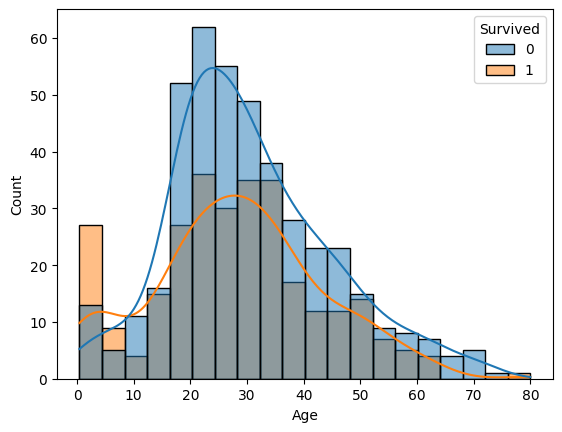

In [ ]:
sns.histplot(data=train_data, x='Age', hue='Survived',kde=True)

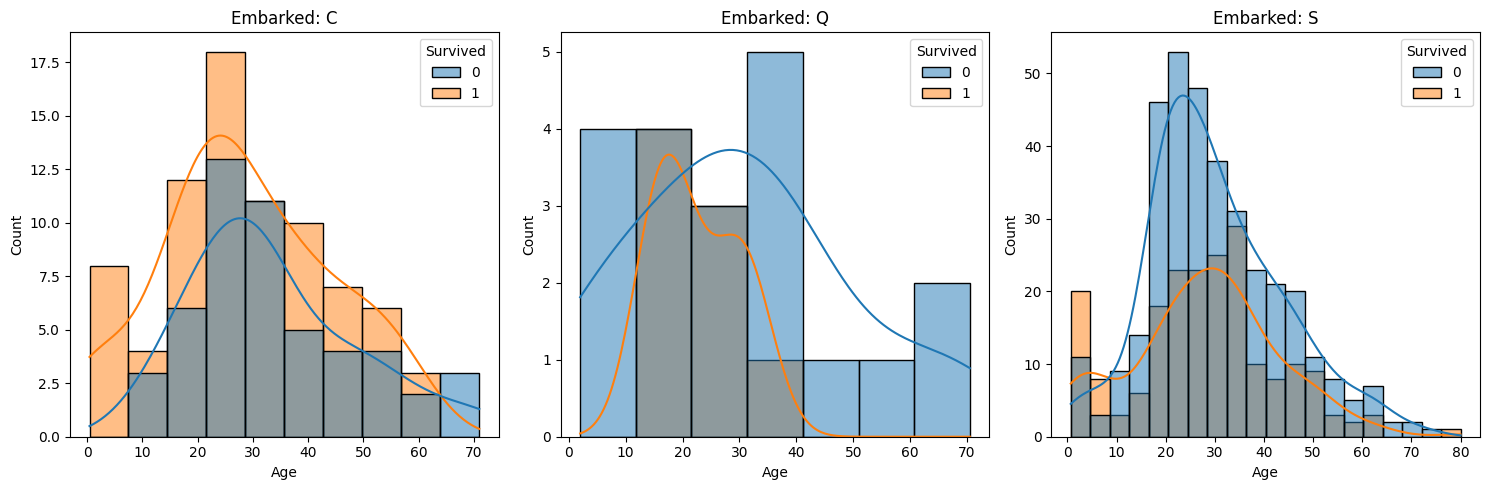

In [ ]:
fig, ax=plt.subplots(1,3,figsize=(15,5))


# ax[0], ax[1], ax[2] 지정 및 sns.histplot 사용
# Embarked 값 대문자 처리 ('S')
sns.histplot(data=train_data[train_data['Embarked']=='C'], x='Age', hue='Survived', kde=True, ax=ax[0])
sns.histplot(data=train_data[train_data['Embarked']=='Q'], x='Age', hue='Survived', kde=True, ax=ax[1])
sns.histplot(data=train_data[train_data['Embarked']=='S'], x='Age', hue='Survived', kde=True, ax=ax[2])

# 그래프 제목 추가 (선택사항)
ax[0].set_title('Embarked: C')
ax[1].set_title('Embarked: Q')
ax[2].set_title('Embarked: S')

plt.tight_layout()
plt.show()
fig.show()

#Q에서 탄 남자 어린이들은 모두 죽음

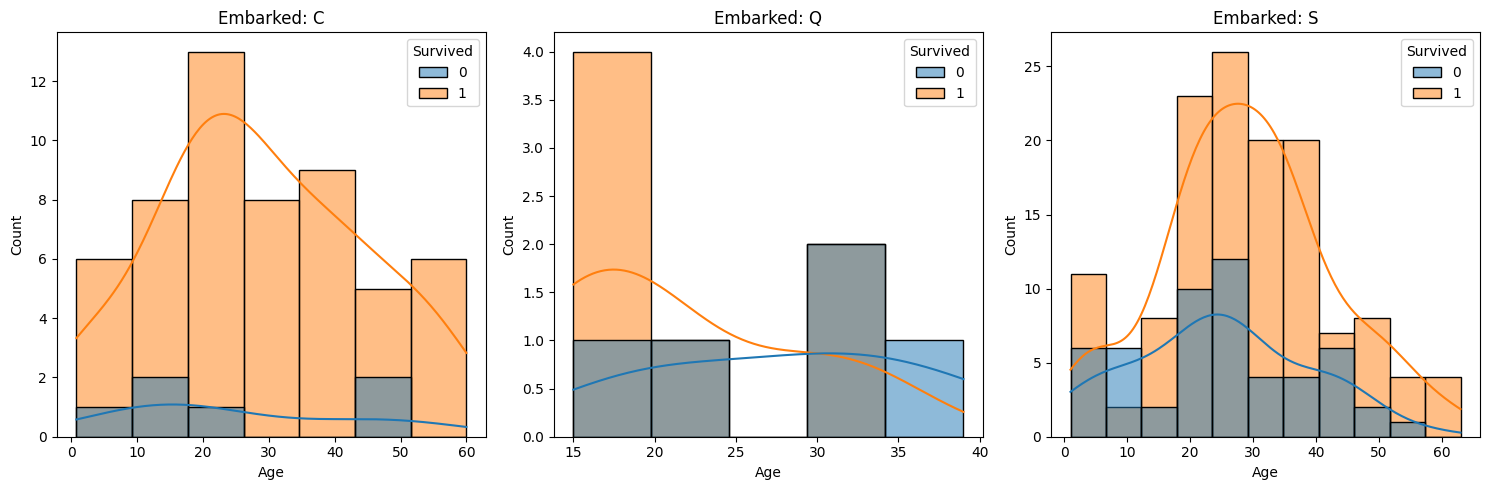

In [ ]:
fig, ax=plt.subplots(1,3,figsize=(15,5))


# ax[0], ax[1], ax[2] 지정 및 sns.histplot 사용
# Embarked 값 대문자 처리 ('S')
sns.histplot(data=train_data[(train_data['Embarked']=='C')&(train_data['Sex']=='female')], x='Age', hue='Survived', kde=True, ax=ax[0])
sns.histplot(data=train_data[(train_data['Embarked']=='Q')&(train_data['Sex']=='female')], x='Age', hue='Survived', kde=True, ax=ax[1])
sns.histplot(data=train_data[(train_data['Embarked']=='S')&(train_data['Sex']=='female')], x='Age', hue='Survived', kde=True, ax=ax[2])

# 그래프 제목 추가 (선택사항)
ax[0].set_title('Embarked: C')
ax[1].set_title('Embarked: Q')
ax[2].set_title('Embarked: S')

plt.tight_layout()
plt.show()
fig.show()

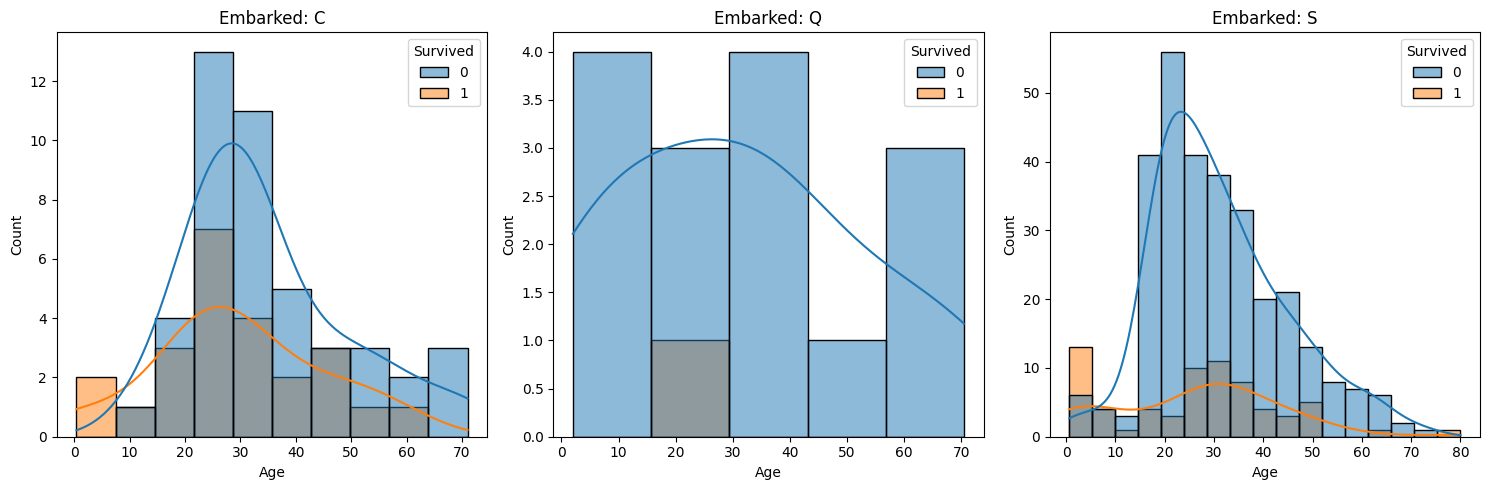

In [ ]:
fig, ax=plt.subplots(1,3,figsize=(15,5))


# ax[0], ax[1], ax[2] 지정 및 sns.histplot 사용
# Embarked 값 대문자 처리 ('S')
sns.histplot(data=train_data[(train_data['Embarked']=='C')&(train_data['Sex']=='male')], x='Age', hue='Survived', kde=True, ax=ax[0])
sns.histplot(data=train_data[(train_data['Embarked']=='Q')&(train_data['Sex']=='male')], x='Age', hue='Survived', kde=True, ax=ax[1])
sns.histplot(data=train_data[(train_data['Embarked']=='S')&(train_data['Sex']=='male')], x='Age', hue='Survived', kde=True, ax=ax[2])

# 그래프 제목 추가 (선택사항)
ax[0].set_title('Embarked: C')
ax[1].set_title('Embarked: Q')
ax[2].set_title('Embarked: S')

plt.tight_layout()
plt.show()
fig.show()

In [ ]:
train_data.pivot_table(index='Sex',columns='Embarked',aggfunc='mean',values='Survived')

Embarked,C,Q,S
Sex,,,
female,0.876712,0.750000,0.689655
male,0.305263,0.073171,0.174603


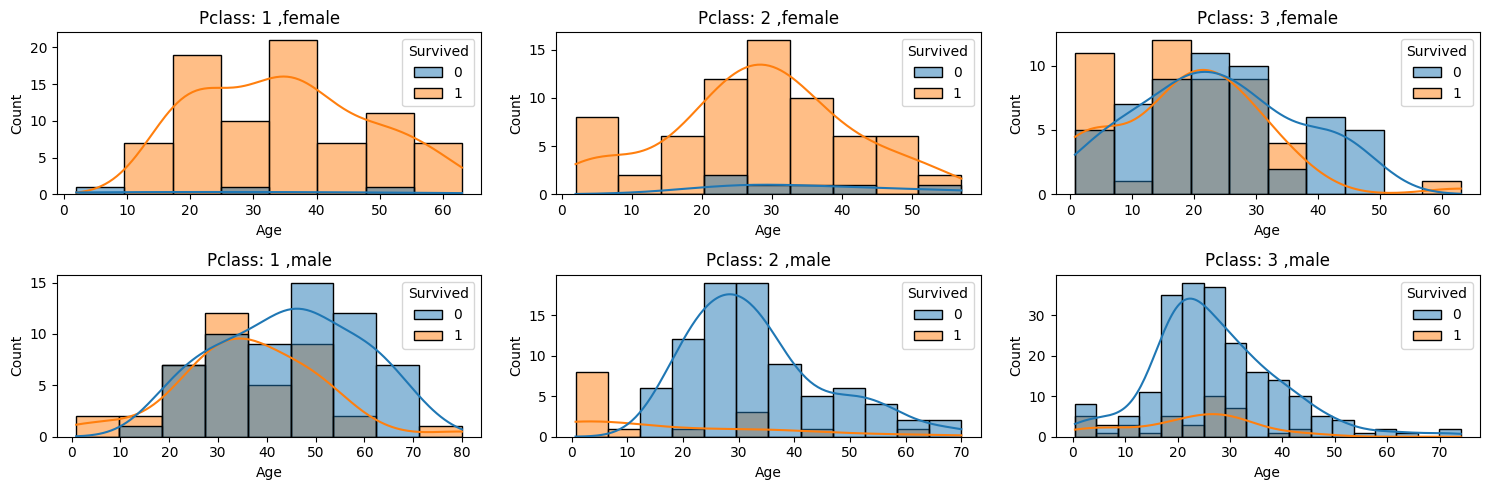

In [ ]:
fig, ax=plt.subplots(2,3,figsize=(15,5))


# ax[0], ax[1], ax[2] 지정 및 sns.histplot 사용
# female

sns.histplot(data=train_data[(train_data['Pclass']==1)&(train_data['Sex']=='female')], x='Age', hue='Survived', kde=True, ax=ax[0,0])
sns.histplot(data=train_data[(train_data['Pclass']==2)&(train_data['Sex']=='female')], x='Age', hue='Survived', kde=True, ax=ax[0,1])
sns.histplot(data=train_data[(train_data['Pclass']==3)&(train_data['Sex']=='female')], x='Age', hue='Survived', kde=True, ax=ax[0,2])

# male
sns.histplot(data=train_data[(train_data['Pclass']==1)&(train_data['Sex']=='male')], x='Age', hue='Survived', kde=True, ax=ax[1,0])
sns.histplot(data=train_data[(train_data['Pclass']==2)&(train_data['Sex']=='male')], x='Age', hue='Survived', kde=True, ax=ax[1,1])
sns.histplot(data=train_data[(train_data['Pclass']==3)&(train_data['Sex']=='male')], x='Age', hue='Survived', kde=True, ax=ax[1,2])

# 그래프 제목 추가 (선택사항)
ax[0,0].set_title('Pclass: 1 ,female')
ax[0,1].set_title('Pclass: 2 ,female')
ax[0,2].set_title('Pclass: 3 ,female')
ax[1,0].set_title('Pclass: 1 ,male')
ax[1,1].set_title('Pclass: 2 ,male')
ax[1,2].set_title('Pclass: 3 ,male')



plt.tight_layout()
plt.show()
fig.show()

#Q에서 탄 남자 어린이들은 모두 죽음
#1,2등석 남자 어린이들과 1등석 10-20대들의 생존율이 남자들 중 상대적으로 높음+ 1등석 남자들의 생존율이 압도적
#여자 3등석에서 노인을 제외하고 생존율이 압도적으로 낮음

In [ ]:
col_dic
#cat_cols분석 끝
#이제 num_cols analysis

{'str_cols': ['Ticket', 'Name', 'Cabin'],
 'cat_cols': ['Pclass', 'Survived', 'Sex', 'Embarked', 'Age_unknown'],
 'num_cols': ['SibSp', 'Fare', 'Parch', 'PassengerId', 'Age']}

In [ ]:
train_data['Fam_num']=train_data['SibSp']+train_data['Parch']
train_data.Fam_num.describe()

,Fam_num
count,891.000000
mean,0.904602
std,1.613459
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,10.000000


In [ ]:
#col_dic['num_cols'].remove('Fam_num')
col_dic

{'str_cols': ['Ticket', 'Name', 'Cabin'],
 'cat_cols': ['Pclass', 'Survived', 'Sex', 'Embarked', 'Age_unknown'],
 'num_cols': ['SibSp', 'Fare', 'Parch', 'PassengerId', 'Age']}

In [ ]:
col_dic['num_cols'].remove('SibSp')
col_dic['num_cols'].remove('Parch')

In [ ]:
col_dic

{'str_cols': ['Ticket', 'Name', 'Cabin'],
 'cat_cols': ['Pclass', 'Survived', 'Sex', 'Embarked', 'Age_unknown'],
 'num_cols': ['Fare', 'PassengerId', 'Age']}

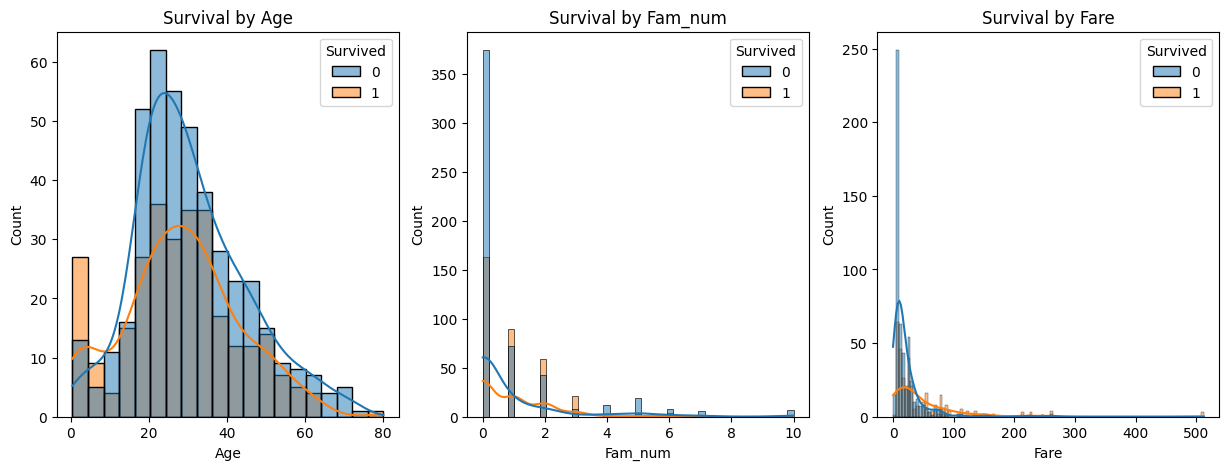

In [ ]:
#Age, Fare, Fam_num-->3개로 num_cols analysis

fig, ax=plt.subplots(1,3,figsize=(15,5))

sns.histplot(x='Age',data=train_data,hue='Survived',kde=True,ax=ax[0])
sns.histplot(x='Fam_num',data=train_data,hue='Survived',kde=True,ax=ax[1])
sns.histplot(x='Fare',data=train_data,hue='Survived',kde=True,ax=ax[2])

ax[0].set_title('Survival by Age')
ax[1].set_title('Survival by Fam_num')
ax[2].set_title('Survival by Fare')


fig.show()

# Someone with Fam_num greater than 3 is probably dead->categorize Fam_num 0/1-3/4-
# When it comes to Fare survival rate has increased from some point->Make groups by that point
# Age is a reliable variable but by the previous experience the model counts on it too much->Combine with categorical columns

#Q에서 탄 남자 어린이들은 모두 죽음
3등석에서 탄 어린이들 사망률 매우 높음
#1,2등석 남자 어린이들과 1등석 10-20대들의 생존율이 남자들 중 상대적으로 높음+ 1등석 남자들의 생존율이 압도적
#여자 3등석에서 노인을 제외하고 생존율이 압도적으로 낮음


# Someone with Fam_num greater than 3 is probably dead
->categorize Fam_num 0/1-3/4-
# When it comes to Fare survival rate has increased from some point
->Make groups from that point
# Age is a reliable variable but by the previous experience the model counts on it too much->Combine with categorical columns

In [ ]:
Name_split1=train_data.Name.str.split(',',expand=True)

In [ ]:
Name_split1.head()
#first name==[0]-->별 의미 없음

,0,1
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry


In [ ]:
Name_split1[0].nunique()

667

In [ ]:
Name_split2=Name_split1[1].str.split('.',expand=True)

In [ ]:
Name_title=Name_split2

In [ ]:
Name_title

,0,1,2
0,Mr,Owen Harris,None
1,Mrs,John Bradley (Florence Briggs Thayer),None
2,Miss,Laina,None
3,Mrs,Jacques Heath (Lily May Peel),None
4,Mr,William Henry,None
...,...,...,...
886,Rev,Juozas,None
887,Miss,Margaret Edith,None
888,Miss,"Catherine Helen ""Carrie""",None
889,Mr,Karl Howell,None


In [ ]:
print(Name_title[0].nunique())
print(Name_title[1].nunique())
print(Name_title[2].unique())


17
799
[None ' Barrett)']


In [ ]:
con=~Name_title[2].isna()
Name_title[con]
#Name_title[1]의미 없음(nunique=799)
#Name_title[2]

,0,1,2
513,Mrs,Martin (Elizabeth L,Barrett)


In [ ]:
train_data['Name_title']=Name_title[0]

In [ ]:
train_data['Family_name']=Name_split1[0]

In [ ]:
col_dic['str_cols']+=['Name_title','Family_name']

In [ ]:
col_dic['str_cols'].remove('Ticket')
col_dic['str_cols'].remove('Cabin')

In [ ]:
name_data=train_data[col_dic['str_cols']]

In [ ]:
train_data.groupby('Name_title')['Survived'].mean().sort_values(ascending=False)
#'Lady','Ms',Sir','Mme','the Countess','Mlle'->전원 생존
#'Capt','Jonkheer','Don','Rev전원 사망

,Survived
Name_title,
Lady,1.000000
Ms,1.000000
Sir,1.000000
Mme,1.000000
the Countess,1.000000
Mlle,1.000000
Mrs,0.792000
Miss,0.697802
Master,0.575000


In [ ]:
train_data.Name_title.value_counts().sort_values(ascending=False)
#Miss,Mrs,Mr,Master정도만 신뢰할만 한 듯
#Dr,Rev는 정 안 되면 추가
#희귀 호칭들은 위의 4개 호칭 중 하나 또는 그 이외로 통합하기
#Dr,Col,Major,Don,Sir,Capt,Jonkheer->Mr
#the Countess,Ms,Mme,Lady->Mrs
#Mle->Miss
#Rev->etc

,count
Name_title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


#Miss,Mrs,Mr,Master정도만 신뢰할만 한 듯
#희귀 호칭들은 위의 4개 호칭 중 하나 또는 그 이외로 통합하기
#Dr,Col,Major,Don,Sir,Capt,Jonkheer->Mr
#the Countess,Ms,Mme,Lady->Mrs
#Mle->Miss
#Rev->etc

In [ ]:
train_data['Fare_zero']= train_data.Fare==0
train_data.groupby('Fare_zero')['Survived'].mean()
#Fare=0인 사람들 사망률 말이 안 되게 높음

,Survived
Fare_zero,
False,0.389269
True,0.066667


In [ ]:
col_dic['cat_cols'].append('Fare_zero')

In [ ]:
train_data[['Ticket','Survived']].head(20)

,Ticket,Survived
0,A/5 21171,0
1,PC 17599,1
2,STON/O2. 3101282,1
3,113803,1
4,373450,0
5,330877,0
6,17463,0
7,349909,0
8,347742,1
9,237736,1


In [ ]:
train_data.Ticket.nunique()

681

In [ ]:
train_data['Same_ticket']=train_data.duplicated(subset='Ticket',keep=False)
train_data.Same_ticket.sum()#--->

np.int64(344)

In [ ]:
train_data.pivot_table(index='Same_ticket',columns='Fam_num',values='PassengerId',aggfunc='count')

Fam_num,0,1,2,3,4,5,6,7,10
Same_ticket,,,,,,,,,
False,462.0,58.0,24.0,1.0,1.0,NaN,1.0,NaN,NaN
True,75.0,103.0,78.0,28.0,14.0,22.0,11.0,6.0,7.0


In [ ]:
train_data.pivot_table(index='Same_ticket',columns='Fam_num',values='Survived',aggfunc='mean')

Fam_num,0,1,2,3,4,5,6,7,10
Same_ticket,,,,,,,,,
False,0.270563,0.413793,0.500000,0.00,1.000000,NaN,1.000000,NaN,NaN
True,0.506667,0.631068,0.602564,0.75,0.142857,0.136364,0.272727,0.0,0.0


Fare가 0인 사람은 압도적으로 생존율이 낮음

같은 티켓을 발급 받은 사람은 같은 Fam_num사람보다 생존율이 높음(Fam_num<=2)
(무슨 상관인지는 모르겠음)

In [ ]:
def data_preprocessor(df):
  data=df.copy()
  data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
  data['Fam_num']=data['SibSp']+data['Parch']

  title_mapping = {
        'Dr': 'Mr', 'Col': 'Mr', 'Major': 'Mr', 'Don': 'Mr', 'Sir': 'Mr',
        'Capt': 'Mr', 'Jonkheer': 'Mr', 'Rev': 'Mr',
        'the Countess': 'Mrs', 'Ms': 'Mrs', 'Mme': 'Mrs', 'Lady': 'Mrs', 'Dona': 'Mrs',
        'Mlle': 'Miss'
    }
  data['Title'] = data['Title'].replace(title_mapping)


  def categorize_Fam(num):
    if num==0:
      return 'sol'
    elif num>4:
      return 'max'
    else:
      return 'proper'
  data['Fam_group']=data['Fam_num'].apply(categorize_Fam)

  def categorize_Fare(money):
    if money==0:
      return 'worker'
    else:
      return 'passenger'

  data['Fare_zero']=data['Fare'].apply(categorize_Fare)

  def categorize_pclasex(df_1):
    data=df_1.copy()
    if data['Pclass']==3 or (data['Pclass']==2 and data['Sex']=='male'):
      return 'unfortunate'
    elif data['Pclass']==1 and data['Sex']=='male':
      return 'rich'
    else:
      return 'ps'
  data['Pclass_sex']=data.apply(categorize_pclasex,axis=1)

  def categorize_embark(df_2):
    data=df_2.copy()

    if data['Embarked']=='Q' and data['Age']<=13:
      return 'bye'
    else:
      return 'hi'
  data['embarked_kid']=data.apply(categorize_embark,axis=1)
  return data


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 1. 데이터 전처리 실행
train_clean = data_preprocessor(train_data)
test_clean = data_preprocessor(test_data)

# 2. 사용할 피처 선택 및 원-핫 인코딩 (문자열 컬럼 -> 수치화)
features = [  'Sex','Title', 'Fam_group', 'Fare_zero', 'Pclass_sex', 'embarked_kid','Age']

X = pd.get_dummies(train_clean[features], drop_first=True)
y = train_clean['Survived']

# 테스트 데이터도 동일하게 인코딩 후 열 맞춤
X_test = pd.get_dummies(test_clean[features], drop_first=True)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0) # test에 없는 열은 0으로 채움

# 3. 모델 정의 및 교차 검증(CV) 점수 확인
model = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(model, X, y, cv=5)

print(f"5-Fold CV 평균 정확도: {scores.mean():.4f}")

# 4. 전체 데이터 학습 및 예측
model.fit(X, y)
predictions = model.predict(X_test)

# 5. 제출 파일 생성 (Kaggle Submission)
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': predictions
})
submission.to_csv('submission_test.csv', index=False)
print("제출 파일 저장 완료: submission_test.csv")

5-Fold CV 평균 정확도: 0.8238
제출 파일 저장 완료: submission_test.csv


In [ ]:
import pandas as pd

# Feature Importance 확인
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))

Age                       0.367464
Title_Mr                  0.165202
Sex_male                  0.163421
Pclass_sex_unfortunate    0.135242
Fam_group_proper          0.044004
Title_Mrs                 0.033214
Title_Miss                0.027300
Fam_group_sol             0.021849
Pclass_sex_rich           0.020049
Title_Master              0.012302
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Train / Test 병합 후 그룹 생존 피처 생성
def apply_wcg_group_rule(train_df, test_df):
    train = train_df.copy()
    test = test_df.copy()

    # 구분값 생성
    train['is_train'] = 1
    test['is_train'] = 0
    test['Survived'] = np.nan

    df = pd.concat([train, test], sort=False).reset_index(drop=True)

    # [1] Title 및 Surname(성씨) 추출
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Surname'] = df['Name'].apply(lambda x: x.split(',')[0].strip())

    # [2] 여성 및 어린이 구분 (생존 우대 집단)
    df['Is_Woman_Or_Child'] = ((df['Sex'] == 'female') | (df['Age'] < 12) | (df['Title'] == 'Master')).astype(int)

    # [3] Ticket 그룹 생성
    df['Ticket_Group'] = df['Ticket']

    # [4] 그룹별 여성/어린이 인원수 계산
    df['Woman_Child_Count'] = df.groupby('Ticket_Group')['Is_Woman_Or_Child'].transform('sum')

    # [5] Train 데이터 기준, 해당 그룹의 여성/어린이 생존율 계산 (Core Rule!)
    # 그룹 내 자신을 제외한 다른 여성/어린이 승객들의 생존 정보 수집
    df['Group_WC_Survived_Mean'] = df[df['Is_Woman_Or_Child'] == 1].groupby('Ticket_Group')['Survived'].transform('mean')
    df['Group_WC_Survived_Mean'] = df.groupby('Ticket_Group')['Group_WC_Survived_Mean'].transform('mean')

    # 그룹 정보가 없는 경우 기본값 0.5 (알 수 없음)
    df['Group_WC_Survived_Mean'] = df['Group_WC_Survived_Mean'].fillna(0.5)

    # 다시 Train / Test 분리
    train_out = df[df['is_train'] == 1].drop(columns=['is_train'])
    test_out = df[df['is_train'] == 0].drop(columns=['is_train', 'Survived'])

    return train_out, test_out

# 2. 전처리 실행
train_wcg, test_wcg = apply_wcg_group_rule(train_data, test_data)

# 3. 모델 학습용 기본 피처 + 그룹 생존 피처
features = ['Pclass', 'Sex', 'Fare', 'Embarked', 'Title', 'Is_Woman_Or_Child', 'Group_WC_Survived_Mean']

# 간단한 전처리 (결측치 채우기)
for d in [train_wcg, test_wcg]:
    d['Fare'] = d['Fare'].fillna(train_wcg['Fare'].median())
    d['Embarked'] = d['Embarked'].fillna('S')

X = pd.get_dummies(train_wcg[features], drop_first=True)
y = train_wcg['Survived'].astype(int)

X_test = pd.get_dummies(test_wcg[features], drop_first=True)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# 4. 모델 학습 (트리 깊이를 얕게 설정)
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
model.fit(X, y)

# 5. 예측 및 제출 파일 생성
predictions = model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': predictions
})
submission.to_csv('submission_wcg_080.csv', index=False)
print("🎯 WCG 룰베이스 기반 파일 저장 완료: submission_wcg_080.csv")

🎯 WCG 룰베이스 기반 파일 저장 완료: submission_wcg_080.csv


In [ ]:
data['Cabin'].fillna(0,inplace=True)
print(data.dtypes)
print(data['Cabin'])

In [ ]:
b=data.groupby(data['Cabin']==0)['Survived']
a=b.sum()/data['Survived'].sum()
data['New_cabin']=data['Cabin'].apply(lambda x:'Not cabin' if x==0 else 'Am cabin')
sns.barplot(x='New_cabin',y=a,data=data)
plt.title('Survival Rate by Cabin')
plt.xlabel('')
plt.ylabel('survival rate')

In [ ]:
print(data.shape)

In [ ]:
print(data['Age'])

In [ ]:
a=data['Age'].isnull().sum()
b=data['Age'].notnull().sum()
print(a)
print(b)


In [ ]:
sns.histplot(x='Age',data=data)


In [ ]:
data['Age_group']=pd.cut(data['Age'],bins=[0,16,28,40,60,100],labels=['child','grownup','adult','mature','elderly'])

In [ ]:
print(data['Age_group'])
sns.histplot(x='Age_group',data=data)


In [ ]:
e=data.groupby('Age_group')['Survived']
print(e.sum()/data['Age_group'].count())
print(e.sum())

In [ ]:
import missingno as msno
msno.matrix(data)

top_30_pubs_idx=ns_book7['출판사'].isin(top_30_pubs.index)
top_30_pubs_idx.sum()
ns_book8=ns_book7[top_30_pubs_idx].sample(10,random_state=42)
ns_book8
ns_book9.sort_values(by='발행년도')

ax.legend()-->범례

참고할만한 문법들